In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Saving porsche.png to porsche.png


(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

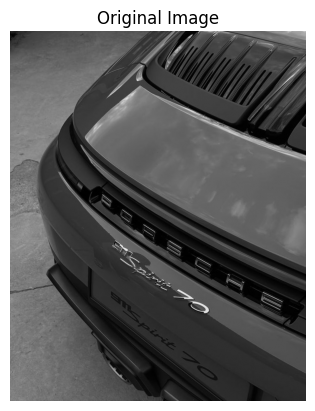

In [2]:
from google.colab import files
uploaded = files.upload()

image = cv2.imread('porsche.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

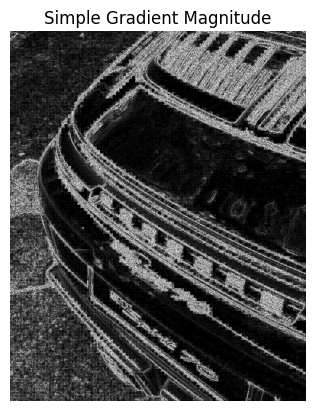

In [3]:
gx = np.zeros_like(image)
gy = np.zeros_like(image)

gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient Magnitude')
plt.axis('off')

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

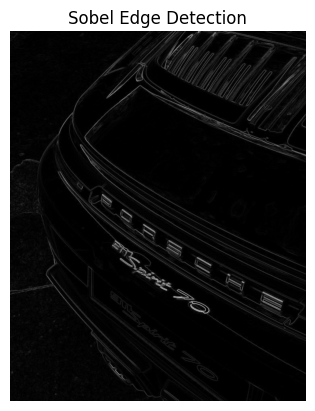

In [4]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

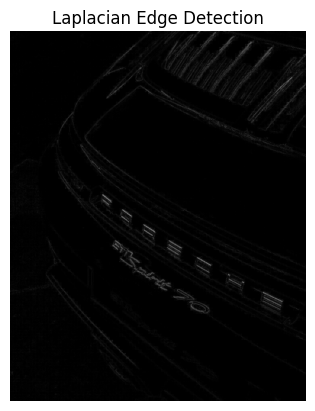

In [5]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

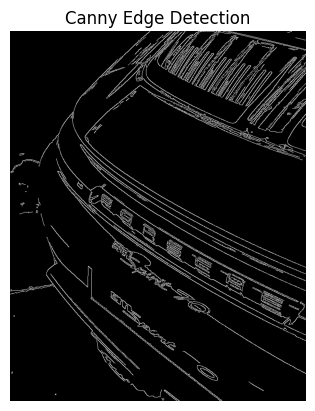

In [6]:
canny = cv2.Canny(image, 100, 200)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

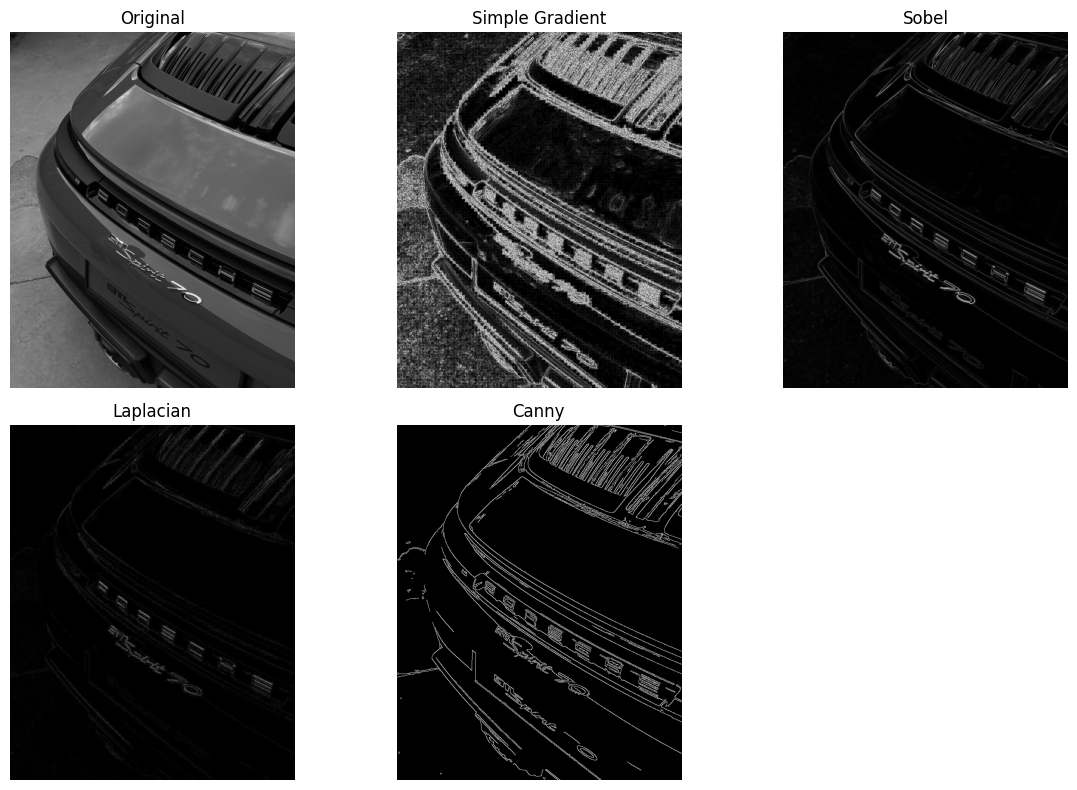

In [7]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

# Exercises


In [10]:
image = cv2.imread('porsche.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

canny1 = cv2.Canny(image, 50, 150)
canny2 = cv2.Canny(image, 100, 200)
canny3 = cv2.Canny(image, 150, 250)

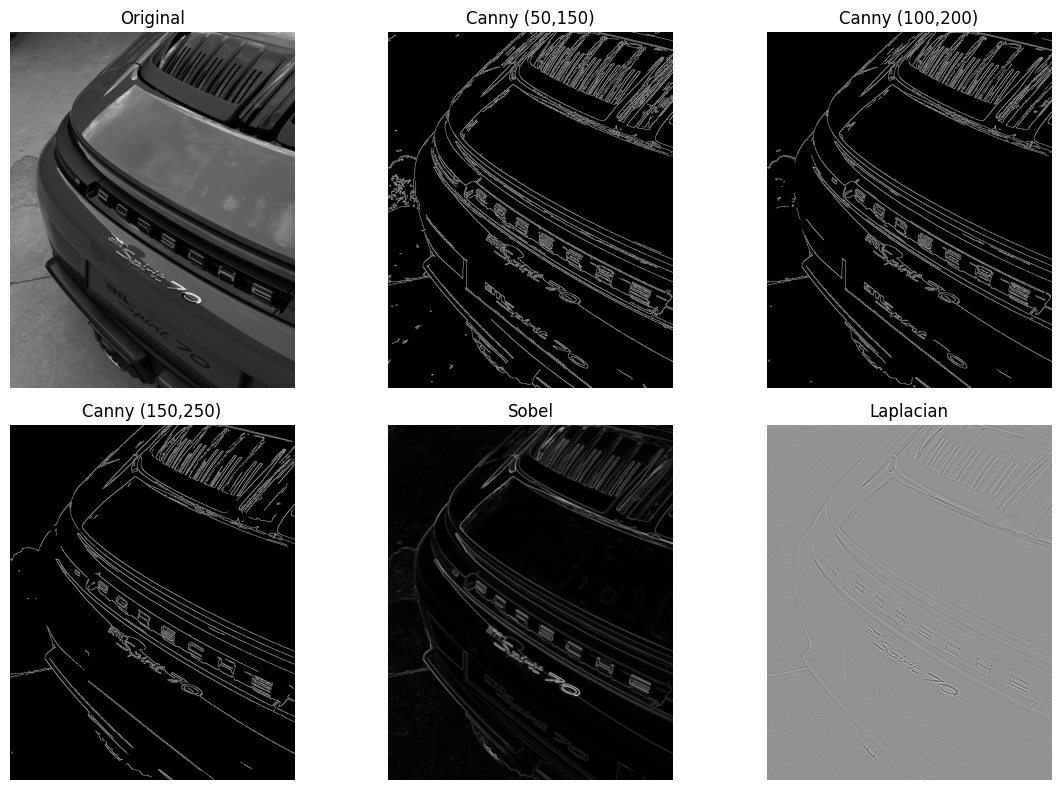

In [11]:
blur = cv2.GaussianBlur(image, (5, 5), 0)

sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.magnitude(sobelx, sobely)


laplacian = cv2.Laplacian(blur, cv2.CV_64F)


titles = [
    'Original',
    'Canny (50,150)', 'Canny (100,200)', 'Canny (150,250)',
    'Sobel',
    'Laplacian'
]

images = [
    image,
    canny1, canny2, canny3,
    sobel,
    laplacian
]

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()